# Universität Hildesheim - Mapping

In [4]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [6]:
client = bigquery.Client(project='subugoe-collaborative')

In [7]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Universität Hildesheim' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02f9det96' -- 'Universität Hildesheim'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [8]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Hildesheim,"Applied Educational Science, University of Hil...",https://openalex.org/W4401907027
1,not assigned,Universität Hildesheim,"Institute of Sport Sciences, Biosciences of Sp...",https://openalex.org/W4390815040
2,not assigned,Universität Hildesheim,Universität Hildesheim,https://openalex.org/W4403773496
3,not assigned,Universität Hildesheim,"Department of Biology, Universität Hildesheim,...",https://openalex.org/W4403773496
4,not assigned,Universität Hildesheim,"Department of Experimental Psychopathology, In...",https://openalex.org/W4399155286


In [413]:
MAPPING_DICT = {
    'Center for World Music (CWM)': ['center for world music'],
    'Centrum für Lehrerbildung und Bildungsforschung (CeLeB)': ['lehrerbildung'],
    'Fachbereich I: Erziehungs- und Sozialwissenschaften': ['education(al)? science', 'psycholog(ie|y)', 'sport', 'erziehungswissenschaft',
                                                            'so(z|c)ial', 'grundschuldidaktik', 'theologie', 'geschichte', '(institute|faculty) of education',
                                                            'psychopathology', 'migration', 'economics education', 'research methods'
                                                           ],
    'Fachbereich II: Kulturwissenschaften und Ästhetische Kommunikation': ['english', 'philosoph(ie|y)', 'kulturpolitik', 'musikwissenschaft',
                                                                           'cultural policy'
                                                                          ],
    'Fachbereich III: Sprach- und Informationswissenschaften': ['language (science|processing)', 'linguistics', 'deutsche sprache', 'informationswissenschaften',
                                                                'sprachtechnologie', 'information science', 'inter(k|c)ultur(elle|al)',
                                                                'übersetzungswissenschaft', 'german language',
                                                               ],
    'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik': ['institut für informatik', 'ecology', 'machine learning',
                                                                                   'biolog(ie|y)', 'angewandte informatik', 'business administration',
                                                                                   'mat(h)?emati(k|cs)', 'geography', 'information systems',
                                                                                   'computer science', 'software systems engineering', 'wirtschaftsinformatik',
                                                                                   'data analytics', 'ismll,'
                                                                                  ],
    #'Universitätsbibliothek': [],
    #'Zentrum für Geschlechterforschung': []
}

In [414]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [415]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [416]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fachbereich I: Erziehungs- und Sozialwissensch...,Universität Hildesheim,"Applied Educational Science, University of Hil...",https://openalex.org/W4401907027
1,Fachbereich I: Erziehungs- und Sozialwissensch...,Universität Hildesheim,"Institute of Sport Sciences, Biosciences of Sp...",https://openalex.org/W4390815040
2,None,Universität Hildesheim,Universität Hildesheim,https://openalex.org/W4403773496
3,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, Universität Hildesheim,...",https://openalex.org/W4403773496
4,Fachbereich I: Erziehungs- und Sozialwissensch...,Universität Hildesheim,"Department of Experimental Psychopathology, In...",https://openalex.org/W4399155286
...,...,...,...,...
1395,None,Universität Hildesheim,"Universität Hildesheim, Universitätsplatz 1, 3...",https://openalex.org/W3216554507
1396,None,Universität Hildesheim,"University of Hildesheim, Hildesheim, Germany",https://openalex.org/W3210958401
1397,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Research Group Plant Ecology and Nature Conser...,https://openalex.org/W3133920704
1398,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Research Group Plant Ecology and Nature Conser...,https://openalex.org/W3133920704


In [417]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['Universität Hildesheim',
       'University of Hildesheim, Hildesheim, Germany',
       'Stiftung Universität Hildesheim',
       'Universität Hildesheim, Hildesheim, Deutschland',
       'University of Hildesheim,Hildesheim,Germany',
       'University of Hildesheim, Germany',
       'Universität Hildesheim, Universitätsplatz\xa01, 31141, Hildesheim, Deutschland',
       'Stiftung Universität Hildesheim, Universitätsplatz\xa01, 31141, Hildesheim, Deutschland',
       '1University of Hildesheim', 'University of Hildesheim , DE',
       'University of Hildesheim, DE',
       'University of Hildesheim,Department of Informatics,Germany',
       'University of Hildesheim',
       'University of Hildesheim (Universitätspl. 1, 31141 Hildesheim - Germany)',
       'University Hildesheim, Hildesheim, Germany',
       'University Hildesheim, Institute for Geograph',
       'Stiftung Universitaet Hildesheim',
       'Stiftung Universität Hildesheim,             Deutschland',
       'Univ

In [418]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Center for World Music (CWM),1
1,Centrum für Lehrerbildung und Bildungsforschun...,4
2,Fachbereich I: Erziehungs- und Sozialwissensch...,486
3,Fachbereich II: Kulturwissenschaften und Ästhe...,30
4,Fachbereich III: Sprach- und Informationswisse...,81
5,"Fachbereich IV: Mathematik, Naturwissenschafte...",326
6,NaN,472


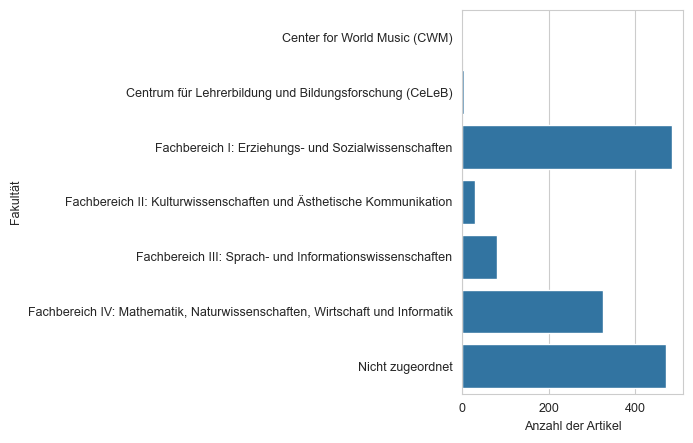

In [419]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [420]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6628571428571428